In [1]:
#### Cellule 1.2.1 #####

  # Chargement du gestionnaire de paquets Julia.
  #Il est utilisé au besoin pour installer les bibliothèques nécessaires.
      using Pkg

  #Bibliothèques de manipulation de données
   using DataFrames, CSV, Dates

   #Bibliothèques de calcul statistique et algébrique
using Statistics, LinearAlgebra

# Bibliothèques d'optimisation mathématique :
# JuMP : modélisation du problème
# Gurobi : solveur d'optimisation
    using JuMP, Gurobi

# Bibliothèque de visualisation graphique
using Plots

# Bibliothèque utile pour le formatage propre de certains affichages
using Printf

  #Import de l'interface MathOptInterface (MOI),
#utilisée en arrière-plan par JuMP pour communiquer avec le solveur.
 import MathOptInterface as MOI

   # Dossier de sortie destiné à stocker les figures et tableaux
  #produits dans cette partie du chapitre.
   OUTDIR = "outputs_chap1_sec1_4"
   isdir(OUTDIR) || mkpath(OUTDIR)

  #Liste des actifs retenus pour l'étude empirique du portefeuille.
TICKERS= ["AAPL", "MSFT", "AMZN", "GOOG", "META"]

  #Capital initial du portefeuille.
 #Cette quantité servira de référence pour interpréter les allocations
 #et les métriques financières en valeur monétaire.
W0= 1_000_000.0

# Nombre usuel de jours de bourse par an.
FREQ= 252 

252

In [3]:
#### Cellule 1.2.2 ####

  #Nom du fichier contenant les prix historiques (généré précédemment)
   PRICE_BASENAME= "prices_tech.csv"

   #Liste de chemins possibles où le fichier peut se trouver.
  #Cela permet de rendre le code robuste à différents environnements
   # (local, notebook, sandbox, etc.).
candidate_paths = [
    joinpath("data", PRICE_BASENAME),
    PRICE_BASENAME,
    joinpath(pwd(), PRICE_BASENAME),
    joinpath(pwd(), "data", PRICE_BASENAME),
    joinpath("/mnt/data", PRICE_BASENAME)  # utile en environnement distant
]

   #Recherche du fichier existant parmi les chemins candidats
PRICE_FILE = nothing
for p in candidate_paths
    if isfile(p)
        PRICE_FILE = p
        break
    end
end

 #Vérification que le fichier a bien été trouvé
@assert PRICE_FILE !== nothing "Fichier introuvable. Cherché: $(candidate_paths). Mets $PRICE_BASENAME dans ./data/ ou adapte le chemin."

#Affichage du chemin retenu
println("Fichier prix utilisé : ", PRICE_FILE)

 #Lecture du fichier CSV dans un DataFrame
prices= CSV.read(PRICE_FILE, DataFrame)

#Vérification de la présence de la colonne Date
  @assert "Date" in names(prices) "Colonne 'Date' absente. Colonnes trouvées: $(names(prices))"

 #Conversion des dates si nécessaire (sécurité de typage)
if !(eltype(prices.Date) <: Date)
    prices.Date = Date.(prices.Date)
end

#Conservation uniquement des colonnes utiles :
 # Date + actifs sélectionnés
 select!(prices, ["Date"; TICKERS]...)

 #Tri des données par ordre chronologique
 sort!(prices, :Date)

# Aperçu des premières et dernières lignes
println("Aperçu des données :")
println("Premières lignes :")
println(first(prices, 3))
println("Dernières lignes :")
println(last(prices, 3))

# Affichage complémentaire
first(prices, 5), last(prices, 5)

Fichier prix utilisé : data\prices_tech.csv
Aperçu des données :
Premières lignes :
3×6 DataFrame
 Row │ Date        AAPL     MSFT     AMZN     GOOG     META    
     │ Date        Float64  Float64  Float64  Float64  Float64 
─────┼─────────────────────────────────────────────────────────
   1 │ 2015-01-02  24.2374  40.1536  15.426   26.2405    78.45
   2 │ 2015-01-05  23.5555  39.7826  15.1095  25.6935    77.19
   3 │ 2015-01-06  23.5575  39.1972  14.7645  25.098     76.15
Dernières lignes :
3×6 DataFrame
 Row │ Date        AAPL     MSFT     AMZN     GOOG     META    
     │ Date        Float64  Float64  Float64  Float64  Float64 
─────┼─────────────────────────────────────────────────────────
   1 │ 2025-12-29   273.76   487.1    232.07   314.39   658.69
   2 │ 2025-12-30   273.08   487.48   232.53   314.55   665.95
   3 │ 2025-12-31   271.86   483.62   230.82   313.8    660.09


(5×6 DataFrame
 Row │ Date        AAPL     MSFT     AMZN     GOOG     META    
     │ Date        Float64  Float64  Float64  Float64  Float64 
─────┼─────────────────────────────────────────────────────────
   1 │ 2015-01-02  24.2374  40.1536  15.426   26.2405    78.45
   2 │ 2015-01-05  23.5555  39.7826  15.1095  25.6935    77.19
   3 │ 2015-01-06  23.5575  39.1972  14.7645  25.098     76.15
   4 │ 2015-01-07  23.8917  39.6975  14.921   25.055     76.15
   5 │ 2015-01-08  24.8079  40.8676  15.023   25.134     78.18, 5×6 DataFrame
 Row │ Date        AAPL     MSFT     AMZN     GOOG     META    
     │ Date        Float64  Float64  Float64  Float64  Float64 
─────┼─────────────────────────────────────────────────────────
   1 │ 2025-12-24   273.81   488.02   232.38   315.67   667.55
   2 │ 2025-12-26   273.4    487.71   232.52   314.96   663.29
   3 │ 2025-12-29   273.76   487.1    232.07   314.39   658.69
   4 │ 2025-12-30   273.08   487.48   232.53   314.55   665.95
   5 │ 2025-12-31  

In [5]:
######## Cellule 1.2.3 ###

#Fonction de calcul des rendements simples :
 #Input : vecteur de prix p[1:T]
 #Output : vecteur de taille T-1 avec R[t] = p[t+1]/p[t] -1

function simple_returns(p::AbstractVector{<:Real})
    return p[2:end] ./ p[1:end-1] .- 1.0
end

 #Fonction de calcul des log-rendements :
 #r[t] = log(p[t+1]/p[t])

function log_returns(p::AbstractVector{<:Real})
    return log.(p[2:end] ./ p[1:end-1])
end

log_returns (generic function with 1 method)

In [7]:
#### Cellule 1.2.4 #####

# Nombre d'observations (dates) et nombre d'actifs
  T= nrow(prices)
    N = length(TICKERS)

  #Initialisation des matrices de rendements :
    #R_simple : rendements simples
    #R_log : log-rendements
  # Dimensions : (T-1) x N car les rendements perdent une observation
   R_simple = Matrix{Float64}(undef, T-1, N)
   R_log = Matrix{Float64}(undef, T-1, N)

# Construction des matrices colonne par colonne (actif par actif)
for (j, tk) in enumerate(TICKERS)

    # Conversion explicite en Float64 pour assurer la compatibilité numérique
    p= Float64.(prices[!, tk])

        #Remplissage des colonnes j avec les rendements correspondants
    R_simple[:, j] = simple_returns(p)
    R_log[:, j] = log_returns(p)
end

# Ajustement des dates associées aux rendements
dates_ret= prices.Date[2:end]

# Affichage des dimensions des matrices
println("Dimensions des rendements :")
println("R_simple : ", size(R_simple))
println("R_log    : ", size(R_log))

Dimensions des rendements :
R_simple : (2765, 5)
R_log    : (2765, 5)


In [9]:
#### Cellule 1.2.5 ####

  #Fonction d'estimation du vecteur des moyennes (μ)
   #et de la matrice de covariance (Σ) à partir des rendements.
function estimate_mu_sigma(R::AbstractMatrix{<:Real})

    #Moyenne empirique des rendements (par actif)
      μ= vec(mean(R, dims=1))

     #Matrice de covariance empirique (sur les observations temporelles)
    Σ = cov(Matrix(R))

    # Symétrisation pour éviter des problèmes numériques
     #(garantir une matrice bien définie pour l'optimisation)
    Σ= 0.5* (Σ + Σ')

    return μ, Σ
end

 #Estimation à partir des rendements simples et logarithmiques
  μS, ΣS = estimate_mu_sigma(R_simple)
  μL, ΣL= estimate_mu_sigma(R_log)

# Annualisation (données journalières ==> base annuelle)
 μS_ann = μS .* FREQ
 ΣS_ann = ΣS .* FREQ

  μL_ann = μL .* FREQ
  ΣL_ann = ΣL .* FREQ

  #Régularisation numérique :
#ajout d’un petit terme sur la diagonale pour éviter
  # les problèmes de conditionnement ou matrices quasi singulières
    ϵ = 1e-10
    ΣS_ann = ΣS_ann + ϵ * I
    ΣL_ann= ΣL_ann + ϵ * I

# Affichage des moyennes annualisées
μS_ann, μL_ann

([0.2619291625488249, 0.26298197989310645, 0.30062682393750073, 0.2676686050130125, 0.26527342819715166], [0.2203191189738143, 0.2268079632222684, 0.24658485160834517, 0.22615763436697614, 0.1941188090291651])

In [11]:
####### Cellule 1.2.6 #####

# Figure 1 : Prix (Close)

# Initialisation du graphique avec le premier actif
p_prices = plot(prices.Date, prices[!, TICKERS[1]],
    xlabel="Date", ylabel="Prix",
    label=TICKERS[1],
    title="Prix journaliers (Close) — 2015–2025",
    linewidth=2
)

 #Ajout des autres actifs au graphique
for j in 2:N
    plot!(p_prices, prices.Date, prices[!, TICKERS[j]],
          label=TICKERS[j], linewidth=2)
end

  #Sauvegarde de la figure
savefig(p_prices, joinpath(OUTDIR, "control_prices_2015_2025.png"))

# Figure 2 : Log-rendements

# Construction d’un DataFrame pour les log-rendements
# (utile pour structurer les données par actif)
df_log = DataFrame(Date = dates_ret)
for (j, tk) in enumerate(TICKERS)
    df_log[!, Symbol(tk)] = R_log[:, j]
end

# Initialisation du graphique avec le premier actif
p_log = plot(df_log.Date, df_log[!, Symbol(TICKERS[1])],
    xlabel="Date", ylabel="Log-return",
    label=TICKERS[1],
    title="Log-rendements — 2015–2025",
    linewidth=1.5
)

# Ajout des autres actifs
for j in 2:N
    plot!(p_log, df_log.Date, df_log[!, Symbol(TICKERS[j])],
          label=TICKERS[j], linewidth=1.5)
end

# Sauvegarde de la figure
savefig(p_log, joinpath(OUTDIR, "control_log_returns_2015_2025.png"))

# Retour des deux graphiques
p_log, p_prices

(Plot{Plots.GRBackend() n=5}, Plot{Plots.GRBackend() n=5})

In [13]:
####### Cellule 1.2.7 ####

# Fonction de résolution du problème moyenne-variance pénalisé :

function solve_mv_penalized(μ::Vector{Float64}, Σ::Matrix{Float64}, η::Float64; silent=true)

     #Nombre d'actifs
     N= length(μ)

    #Symétrisation de la matrice de covariance pour renforcer
     #la stabilité numérique du problème quadratique
    Σ= 0.5* (Σ + Σ')

     #Création du modèle d'optimisation avec le solveur Gurobi
    model= Model(Gurobi.Optimizer)

     # Option pour désactiver l'affichage détaillé du solveur
    if silent
        set_silent(model)
    end

      # Variables de décision :
     #x[i] représente la proportion investie dans l’actif i
    #avec contrainte de vente à découvert interdite
    @variable(model, x[1:N] >= 0.0)

    # Contrainte budgétaire : toute la richesse est investie
    @constraint(model, sum(x) == 1.0)

     #Fonction objectif quadratique :
    #η x'Σx mesure le risque pénalisé
     #μ'x mesure le rendement espéré
     #On minimise donc un compromis risque-rendement
    @objective(model, Min,
        η *sum(Σ[i,j] * x[i] *x[j] for i in 1:N, j in 1:N)
        - sum(μ[i] * x[i] for i in 1:N)
    )

     #Lancement de l'optimisation
    optimize!(model)

    #Vérification du statut de résolution
    status = termination_status(model)
    if status != MOI.OPTIMAL
        error("Optimization failed with status: $status")
    end

     #Récupération de la solution optimale
    xopt= value.(x)

    # Valeur optimale de la fonction objectif
    obj= objective_value(model)

     #Rendement espéré du portefeuille optimal
    er= dot(μ, xopt)

    # Variance du portefeuille optimal
    var =dot(xopt, Σ* xopt)

    # Volatilité du portefeuille optimal
    vol = sqrt(var)

    # Retour :
      # poids optimaux
      # valeur de l’objectif
      # rendement espéré
      # variance
      # volatilité
    return xopt, obj, er, var, vol
end

solve_mv_penalized (generic function with 1 method)

In [15]:
#### Cellule 1.2.8 ######

# Définition de l’intervalle du paramètre d’aversion au risque η
   η_min= 1e-2
   η_max= 1e2

 #Nombre de points dans la grille (approximation quasi continue)
  K= 200

 #Construction d’une grille logarithmique :
#permet de couvrir efficacement plusieurs ordres de grandeur
   u= range(log10(η_min), log10(η_max), length=K)
    η_grid= 10 .^ collect(u)

# Affichage des informations principales
println("Grille η :")
println("η_min = ", first(η_grid))
println("η_max = ", last(η_grid))
println("Nombre de points = ", length(η_grid))

Grille η :
η_min = 0.010000000000000002
η_max = 100.0
Nombre de points = 200


In [17]:
##### Cellule 1.2.9 #######

# Initialisation d’une table pour stocker les résultats de l’optimisation
 #pour chaque valeur du paramètre η. Il s'agit des log-rendements
results_log = DataFrame(
    η = Float64[],   # paramètre d’aversion au risque
    log10η = Float64[],   # échelle logarithmique (utile pour visualisation)
    ER = Float64[], # rendement espéré
    Var = Float64[],   # variance
    Vol = Float64[],  #volatilité
    Obj = Float64[]  #valeur de la fonction objectif
)

 # Matrice pour stocker les poids optimaux pour chaque η
  #Dimensions : K (nombre de points) x N (nombre d’actifs)
Xlog = Matrix{Float64}(undef, K, N)

#Boucle sur la grille des paramètres η
for (k, η) in enumerate(η_grid)

    #Résolution du problème moyenne-variance pénalisé
     xopt, obj, er, var, vol = solve_mv_penalized(μL_ann, ΣL_ann, η)

    #Stockage des poids optimaux
      Xlog[k, :] = xopt

    #Ajout des résultats dans la table
     push!(results_log, (η, log10(η), er, var, vol, obj))
end

# Aperçu des premiers résultats
first(results_log, 5)

Set parameter Username
Set parameter LicenseID to value 2742579
Academic license - for non-commercial use only - expires 2026-11-20
Set parameter Username
Set parameter LicenseID to value 2742579
Academic license - for non-commercial use only - expires 2026-11-20
Set parameter Username
Set parameter LicenseID to value 2742579
Academic license - for non-commercial use only - expires 2026-11-20
Set parameter Username
Set parameter LicenseID to value 2742579
Academic license - for non-commercial use only - expires 2026-11-20
Set parameter Username
Set parameter LicenseID to value 2742579
Academic license - for non-commercial use only - expires 2026-11-20
Set parameter Username
Set parameter LicenseID to value 2742579
Academic license - for non-commercial use only - expires 2026-11-20
Set parameter Username
Set parameter LicenseID to value 2742579
Academic license - for non-commercial use only - expires 2026-11-20
Set parameter Username
Set parameter LicenseID to value 2742579
Academic lic

Row,η,log10η,ER,Var,Vol,Obj
,Float64,Float64,Float64,Float64,Float64,Float64
1,0.01,-2.0,0.246585,0.107616,0.328049,-0.245509
2,0.0104737,-1.9799,0.246585,0.107616,0.328049,-0.245458
3,0.0109699,-1.9598,0.246585,0.107616,0.328049,-0.245404
4,0.0114895,-1.9397,0.246585,0.107616,0.328049,-0.245348
5,0.0120338,-1.9196,0.246585,0.107616,0.328049,-0.24529


In [19]:
####### Cellule 1.2.10 ############

# Initialisation d’une table pour stocker les résultats obtenus
# avec les rendements simples, pour chaque valeur de η
results_simple = DataFrame(
    η = Float64[],      # paramètre d’aversion au risque
    log10η = Float64[],  # version logarithmique de η
    ER = Float64[],    # rendement espéré du portefeuille optimal
    Var = Float64[],   # variance du portefeuille optimal
    Vol = Float64[],    # volatilité du portefeuille optimal
    Obj = Float64[]   # valeur de la fonction objectif
)

   #Matrice de stockage des poids optimaux :
 #chaque ligne correspond à une valeur de η,
 #chaque colonne à un actif

Xsimple = Matrix{Float64}(undef, K, N)

  #Résolution du problème moyenne-variance pénalisé
 #pour chaque valeur de la grille η, à partir des rendements simples
for (k, η) in enumerate(η_grid)
    xopt, obj, er, var, vol = solve_mv_penalized(μS_ann, ΣS_ann, η)

     #Stockage des poids optimaux
    Xsimple[k, :] = xopt

    #Ajout des résultats dans la table
    push!(results_simple, (η, log10(η), er, var, vol, obj))
end

#Aperçu des premiers résultats
first(results_simple, 5)

Set parameter Username
Set parameter LicenseID to value 2742579
Academic license - for non-commercial use only - expires 2026-11-20
Set parameter Username
Set parameter LicenseID to value 2742579
Academic license - for non-commercial use only - expires 2026-11-20
Set parameter Username
Set parameter LicenseID to value 2742579
Academic license - for non-commercial use only - expires 2026-11-20
Set parameter Username
Set parameter LicenseID to value 2742579
Academic license - for non-commercial use only - expires 2026-11-20
Set parameter Username
Set parameter LicenseID to value 2742579
Academic license - for non-commercial use only - expires 2026-11-20
Set parameter Username
Set parameter LicenseID to value 2742579
Academic license - for non-commercial use only - expires 2026-11-20
Set parameter Username
Set parameter LicenseID to value 2742579
Academic license - for non-commercial use only - expires 2026-11-20
Set parameter Username
Set parameter LicenseID to value 2742579
Academic lic

Row,η,log10η,ER,Var,Vol,Obj
,Float64,Float64,Float64,Float64,Float64,Float64
1,0.01,-2.0,0.300627,0.108433,0.329292,-0.299542
2,0.0104737,-1.9799,0.300627,0.108433,0.329292,-0.299491
3,0.0109699,-1.9598,0.300627,0.108433,0.329292,-0.299437
4,0.0114895,-1.9397,0.300627,0.108433,0.329292,-0.299381
5,0.0120338,-1.9196,0.300627,0.108433,0.329292,-0.299322


In [21]:
####### Cellule 1.2.11 #########

 #Portefeuille équipondéré :
 #chaque actif reçoit une part égale 1/N
   xEW = fill(1.0/N, N)

# --- Métriques pour les log-rendements ---

     # Rendement espéré du portefeuille équipondéré
       ER_EW_log  = dot(μL_ann, xEW)

     # Variance du portefeuille équipondéré
      Var_EW_log = dot(xEW, ΣL_ann * xEW)

     # Volatilité (racine de la variance)
      Vol_EW_log = sqrt(Var_EW_log)

# --- Métriques pour les rendements simples ---

   ER_EW_simple= dot(μS_ann, xEW)
   Var_EW_simple = dot(xEW, ΣS_ann * xEW)
  Vol_EW_simple = sqrt(Var_EW_simple)

# Affichage des résultats
println("Equal-weight baseline (log) :")
println("ER = ", ER_EW_log, ", Vol = ", Vol_EW_log)

println("Equal-weight baseline (simple) :")
println("ER = ", ER_EW_simple, ", Vol = ", Vol_EW_simple)

Equal-weight baseline (log) :
ER = 0.22279767544011383, Vol = 0.25682708979946184
Equal-weight baseline (simple) :
ER = 0.27169599991791926, Vol = 0.2566850232551653


In [23]:
######## Cellule 1.2.12 #########

# Calcul de la richesse espérée à horizon 1 an (approximation)

    #  Rendements simples :
      # E[W1] = W0 * (1 + ER)
    #  Log-rendements :
      # E[W1] ≈ W0 * exp(ER)

 # Application aux portefeuilles optimaux
   results_log.EW1 = W0 .* exp.(results_log.ER)
   results_simple.EW1 = W0 .* (1 .+ results_simple.ER)

#Application au portefeuille équipondéré (benchmark)
 EW1_EW_log = W0 * exp(ER_EW_log)
 EW1_EW_simple = W0 * (1 + ER_EW_simple)

# Affichage des résultats
EW1_EW_log, EW1_EW_simple

(1.2495677299175858e6, 1.2716959999179193e6)

In [25]:
######## Cellule 1.2.13 #########

  #Valeurs sélectionnées du paramètre η pour affichage
  #ça nous a permis de résumer la frontière efficiente)
η_show = [1e-2, 5e-2, 1e-1, 5e-1, 1.0, 2.0, 5.0, 10.0, 50.0, 100.0]

  #Fonction d'extraction d’un tableau synthétique à partir des résultats complets
function extract_table(results::DataFrame, η_show::Vector{Float64})

    # Initialisation du DataFrame de sortie
    df = DataFrame()
    df.η = η_show
    df.log10η = log10.(η_show)
    df.ER = similar(η_show)
    df.Vol = similar(η_show)
    df.Var = similar(η_show)
    df.EW1 = similar(η_show)

      #Pour chaque valeur de η demandée,
    #on récupère la ligne la plus proche dans les résultats calculés
    for (i, η) in enumerate(η_show)

        # Recherche de l’indice le plus proche dans la grille η_grid
        idx = argmin(abs.(results.η .- η))

        #Extraction des métriques correspondantes
        df.ER[i] = results.ER[idx]
        df.Var[i] = results.Var[idx]
        df.Vol[i] = results.Vol[idx]
        df.EW1[i] = results.EW1[idx]
    end

    return df
end

#Tables synthétiques pour log-rendements et rendements simples
tab_log= extract_table(results_log, η_show)
tab_simple = extract_table(results_simple, η_show)

# Affichage
tab_log, tab_simple

(10×6 DataFrame
 Row │ η        log10η    ER        Vol       Var        EW1       
     │ Float64  Float64   Float64   Float64   Float64    Float64   
─────┼─────────────────────────────────────────────────────────────
   1 │    0.01  -2.0      0.246585  0.328049  0.107616   1.27965e6
   2 │    0.05  -1.30103  0.246585  0.328049  0.107616   1.27965e6
   3 │    0.1   -1.0      0.246585  0.328049  0.107616   1.27965e6
   4 │    0.5   -0.30103  0.235117  0.262699  0.069011   1.26506e6
   5 │    1.0    0.0      0.230805  0.250174  0.0625868  1.25961e6
   6 │    2.0    0.30103  0.228438  0.246516  0.0607704  1.25664e6
   7 │    5.0    0.69897  0.227012  0.245482  0.0602614  1.25484e6
   8 │   10.0    1.0      0.226543  0.245337  0.0601903  1.25426e6
   9 │   50.0    1.69897  0.226168  0.245291  0.0601676  1.25379e6
  10 │  100.0    2.0      0.226122  0.245289  0.0601669  1.25373e6, 10×6 DataFrame
 Row │ η        log10η    ER        Vol       Var        EW1       
     │ Float64  Float64   

In [27]:
#### Cellule 1.2.14 ########

#Sauvegarde des résultats complets (toutes les valeurs de η)
CSV.write(joinpath(OUTDIR, "results_log_full.csv"), results_log)
CSV.write(joinpath(OUTDIR, "results_simple_full.csv"), results_simple)

 #Sauvegarde des tables synthétiques (η sélectionnés)
CSV.write(joinpath(OUTDIR, "table_log_selected_eta.csv"), tab_log)
CSV.write(joinpath(OUTDIR, "table_simple_selected_eta.csv"), tab_simple)

# Message de confirmation (remplacement de @info)
println("Tables exportées vers : ", OUTDIR)

Tables exportées vers : outputs_chap1_sec1_4


In [29]:
######## Cellule 1.2.15 #########

# --- Figure 1 : Frontière efficiente (log-rendements) ---

    # Tracé de la relation rendement–risque (frontière efficiente)
      p1 = plot(results_log.Vol, results_log.ER,
        xlabel="Volatilité (annualisée)",
        ylabel="Rendement espéré (annualisé)",
        legend=:bottomright,
        label="MV pénalisé (log-rendements)",
       linewidth=2
    )

     # Ajout du portefeuille équipondéré (benchmark)
     scatter!(p1, [Vol_EW_log], [ER_EW_log],
         label="Équipondéré (log)", markersize=6)

     #Sauvegarde de la figure
      savefig(p1, joinpath(OUTDIR, "chap1_sec1_4_fig1_risk_return_log.png"))

# ---Figure 2 : Frontière efficiente (rendements simples) ---

      p2 = plot(results_simple.Vol, results_simple.ER,
        xlabel="Volatilité (annualisée)",
        ylabel="Rendement espéré (annualisé)",
       legend=:bottomright,
       label="MV pénalisé (rendements simples)",
       linewidth=2
     )

# Ajout du portefeuille équipondéré
scatter!(p2, [Vol_EW_simple], [ER_EW_simple],
         label="Équipondéré (simple)", markersize=6)

# Sauvegarde de la figure
savefig(p2, joinpath(OUTDIR, "chap1_sec1_4_fig2_risk_return_simple.png"))

# Retour des deux graphiques
p1, p2

(Plot{Plots.GRBackend() n=2}, Plot{Plots.GRBackend() n=2})

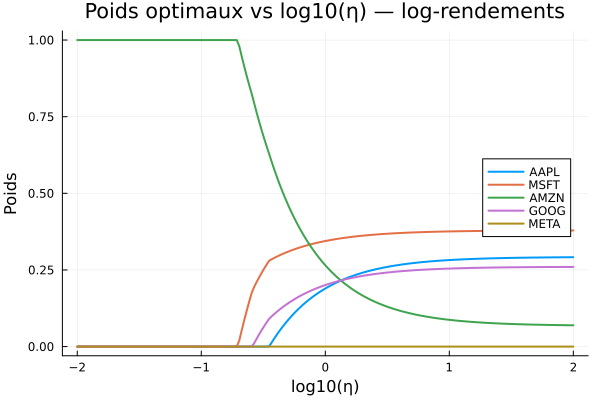

In [31]:
####### Cellule 1.2.16 #########

  #Création du graphique des poids optimaux en fonction de log10(η)
#Cela permet d’analyser comment la composition du portefeuille évolue
#avec l’aversion au risque.
pW = plot(
    xlabel="log10(η)",
    ylabel="Poids",
    legend=:right,
    title="Poids optimaux vs log10(η) — log-rendements"
)

 #Ajout des courbes pour chaque actif
  #Chaque ligne correspond à un actif et montre l'évolution de son poids
  #dans le portefeuille optimal en fonction de η.
for j in 1:N
    plot!(pW,
          results_log.log10η,
          Xlog[:, j],
          label=TICKERS[j],
          linewidth=2)
end

# Sauvegarde de la figure
savefig(pW, joinpath(OUTDIR, "chap1_sec1_4_fig3_weights_vs_eta_log.png"))

# Affichage du graphique
pW

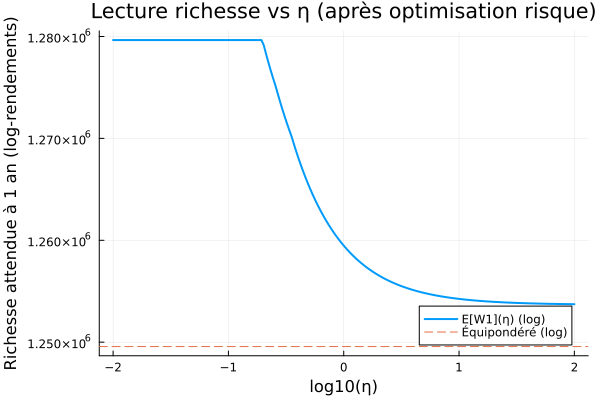

In [33]:
######## Cellule 1.2.17 ########

  #Tracé de la richesse attendue à horizon 1 an en fonction de log10(η)
#Cela permet d’analyser l’impact de l’aversion au risque sur la richesse finale.
pR = plot(results_log.log10η, results_log.EW1,
    xlabel="log10(η)",
    ylabel="Richesse attendue à 1 an (log-rendements)",
    legend=:bottomright,
    label="E[W1](η) (log)",
    linewidth=2,
    title="Lecture richesse vs η (après optimisation risque)"
)

  # Ajout d’une ligne horizontale correspondant au portefeuille équipondéré
   #(benchmark de comparaison)
hline!(pR, [EW1_EW_log],
       label="Équipondéré (log)",
       linestyle=:dash)

# Sauvegarde de la figure
savefig(pR, joinpath(OUTDIR, "chap1_sec1_4_fig4_wealth_vs_eta_log.png"))

# Affichage
pR

In [35]:
######## Cellule 1.2.18 #####

  #Choix d’une valeur spécifique du paramètre η
#permettant d’analyser un portefeuille optimal particulier
 η0= 1.0
#η0 = 5.0
#η0 = 10.0
#η0 = 50.0

  #Recherche de l’indice correspondant dans les résultats
  #(valeur de η la plus proche dans la grille)
  idx0= argmin(abs.(results_log.η .- η0))

# Extraction des caractéristiques du portefeuille optimal
x0 = Xlog[idx0, :]    # poids optimaux
 ER0= results_log.ER[idx0]   # rendement espéré
Vol0 = results_log.Vol[idx0]    # volatilité
EW10 = results_log.EW1[idx0]    # richesse attendue

# Construction d’un tableau comparatif :
# portefeuille optimisé vs portefeuille équipondéré
baseline = DataFrame(
    Portefeuille = ["Optimisé (η=$(η0))", "Équipondéré"],
    ER  = [ER0, ER_EW_log],
    Vol = [Vol0, Vol_EW_log],
    EW1 = [EW10, EW1_EW_log]
)

# Affichage du tableau
baseline

Row,Portefeuille,ER,Vol,EW1
,String,Float64,Float64,Float64
1,Optimisé (η=1.0),0.230805,0.250174,1.25961e6
2,Équipondéré,0.222798,0.256827,1.24957e6


In [37]:
####### Cellule 1.2.19 #######

  #Initialisation d’un DataFrame contenant d’abord
 #les valeurs de η et de log10(η)
weights_log = DataFrame(results_log[:, [:η, :log10η]])

   #Ajout des colonnes de poids optimaux actif par actif
  #Chaque colonne x_TICKER contient les allocations optimales
   #obtenues pour les différentes valeurs de η
for j in 1:N
    weights_log[!, Symbol("x_" * TICKERS[j])] = Xlog[:, j]
end

#Affichage des premières lignes du tableau
first(weights_log, 10)

Row,η,log10η,x_AAPL,x_MSFT,x_AMZN,x_GOOG,x_META
,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,0.01,-2.0,8.95058e-10,1.68497e-9,1.0,2.77094e-9,1.26384e-10
2,0.0104737,-1.9799,1.7757e-9,3.30553e-9,1.0,4.42658e-9,1.27973e-9
3,0.0109699,-1.9598,4.63499e-9,8.44818e-9,1.0,2.70363e-9,3.98254e-9
4,0.0114895,-1.9397,8.27719e-9,1.45635e-8,1.0,1.56966e-9,6.92647e-9
5,0.0120338,-1.9196,3.37495e-9,4.13658e-10,1.0,5.27146e-9,2.75061e-9
6,0.0126038,-1.8995,3.65614e-9,6.60801e-10,1.0,5.87107e-9,2.98896e-9
7,0.0132009,-1.8794,4.04769e-9,1.15113e-9,1.0,6.60292e-9,3.26159e-9
8,0.0138262,-1.8593,4.59282e-9,1.97461e-9,1.0,7.49564e-9,3.57552e-9
9,0.0144812,-1.8392,5.35077e-9,3.254e-9,1.0,8.58514e-9,3.93859e-9
